In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
from modules import data_loader, metrics, learning, plotting, utils, params, pipelines, prunning
from models.gmp import GMP
from models.lstm import LSTM, KPLSTM
from models.gru import GRU, KPGRU
from models.leann import LEANN
from models.rtdtnn import RTDTNN, TransformerEncoderBlock, PositionalEncoding
from models.base_model import BaseModel
from models.tcn import TCN, KPTCN
from models.kp_module import KPModule, KPConvModule
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd

Load data from files and init acpr meter

In [5]:
M = 5

dataset_path = "datasets/Custom_dataset"

container = data_loader.DataContainer()
container.load_data(file_path=dataset_path)
container.cut_signals(M)
container.get_gained_signals()
print(f"gain: {container.gain}")

acpr_meter = metrics.ACPR(
        sample_rate=container.input_signal_fs,
        main_measurement_bandwidth=container.bw_main_ch,
        adjacent_channel_offset=[-container.sub_ch, container.sub_ch],
        segment_length=container.nperseg,
        overlap_percentage=60,
        window='blackmanharris',
        fft_length=container.nperseg,
        power_units='dBW',
        return_main_power=True,
        return_adjacent_powers=True
    )



gain: 7.750391483306885


In [6]:
frame_length = 64
batch_size = 128
batch_size_eval = 2048

pa_train_loader, pa_val_loader, pa_input_norm, pa_target_norm = data_loader.build_dataloaders(container, 
                                                                                              frame_length=frame_length, 
                                                                                              batch_size=batch_size, 
                                                                                              batch_size_eval=batch_size_eval, 
                                                                                              arch="pa",
                                                                                              normalize_method=None)
dla_train_loader, dla_val_loader, dla_input_norm, dla_target_norm = data_loader.build_dataloaders(container, 
                                                                                                  frame_length=frame_length, 
                                                                                                  batch_size=batch_size, 
                                                                                                  batch_size_eval=batch_size_eval, 
                                                                                                  arch="dla",
                                                                                                  normalize_method=None)
ila_train_loader, ila_val_loader, ila_input_norm, ila_target_norm = data_loader.build_dataloaders(container, 
                                                                                                  frame_length=frame_length, 
                                                                                                  batch_size=batch_size, 
                                                                                                  batch_size_eval=batch_size_eval, 
                                                                                                  arch="ila",
                                                                                                  normalize_method=None)

criterion = metrics.compute_mse
metric_criterion = metrics.compute_nmse


In [ ]:
# class KPLSTMCombined(BaseModel, torch.nn.Module):
#     def __init__(self, 
#                  M: int = 5,
#                  hidden_size: int = 5, 
#                  num_layers: int = 1, 
#                  output_size: int = 2, 
#                  bidirectional: bool = False, 
#                  batch_first: bool = True,
#                  bias: bool = False, 
#                  model_name: str = ""):
        
#         torch.nn.Module.__init__(self)
#         BaseModel.__init__(self, model_name=model_name)
        
#         self.kp_module = KPConvModule(M=M)
        
#         feature_dim = self.kp_module.get_feature_dim()
        
#         self.hidden_size = hidden_size
#         self.num_layers = num_layers
#         self.output_size = output_size
#         self.bidirectional = bidirectional
#         self.batch_first = batch_first
#         self.bias = bias
#         self.num_directions = 2 if bidirectional else 1
        
#         reduced_dim = 4
#         self.kp_proj = torch.nn.Linear(feature_dim, reduced_dim)

#         self.lstm = torch.nn.LSTM(input_size=reduced_dim,
#                                   hidden_size=hidden_size,
#                                   num_layers=num_layers,
#                                   bidirectional=bidirectional,
#                                   batch_first=batch_first,
#                                   bias=bias)
                
#         self.fc_out = torch.nn.Linear(in_features=hidden_size * self.num_directions,
#                                       out_features=output_size,
#                                       bias=bias)
    
#     @utils.complex_handler
#     def forward(self, x, h_0=None, c_0=None):
#         """
#         x: [batch, seq_len, 2]
#         """
        
#         B = x.shape[0]
        
#         if h_0 is None:
#             h_0 = torch.zeros(self.num_directions * self.num_layers,
#                               B, 
#                               self.hidden_size)
#         if c_0 is None:
#             c_0 = torch.zeros(self.num_directions * self.num_layers,
#                               B, 
#                               self.hidden_size)
        
#         kp_features = self.kp_module(x)  # [B, T, F, 2]
#         B, T, F, C = kp_features.shape
#         kp = kp_features.reshape(B, T, F * C)
#         kp = self.kp_proj(kp)
                
#         lstm_out, (h_n, c_n) = self.lstm(kp, (h_0, c_0))

#         output = self.fc_out(lstm_out)
        
#         return output
    
#     def _get_filename(self):
#         return (
#             f"{self.model_name}_KPLSTM_"
#             f"hs{self.hidden_size}_nl{self.num_layers}_"
#             f"M{self.kp_module.M}_K{self.kp_module.K}_"
#             f"bi{int(self.bidirectional)}.pt"
#         )

In [ ]:
class KPLEANNCombined(BaseModel, torch.nn.Module):
    def __init__(self, 
                 M: int, 
                 L2: int, 
                 L3: int,
                 K: int, 
                 L1: int = 2,
                 model_name: str = ""):
        
        torch.nn.Module.__init__(self)
        BaseModel.__init__(self, model_name=model_name)
        
        self.M = M
        self.L2 = L2
        self.L3 = L3
        self.K = K
        self.L1 = L1
        
        # KP-модуль
        self.kp_module = KPModule(M=M)
        
        self.leann = LEANN(M=M, L2=L2, L3=L3, L1=L1, K=K)
        
        # Размерность после KP
        feature_dim = self.kp_module.get_feature_dim()
        kp_dim = self.kp_module.kp_dim
        
        self.kp_projection = torch.nn.Linear(in_features=kp_dim, out_features=2*self.L1)
    
    @utils.complex_handler
    def forward(self, x):
        """
        x: [batch, seq_len, 2]
        """
        B = x.shape[0]
        print(f"x.shape: {x.shape}")
        
        # KP-модуль
        kp_features = self.kp_module(x)
        print(f"kp_features.shape: {kp_features.shape}")
        
        kp = kp_features.mean(dim=1)
        kp = kp.reshape(B, -1)

        u = self.kp_projection(kp)
        
        amplitude, phase = self.leann.vdm(u)
        v = self.leann.lea_1(amplitude)
        h = self.leann.lea_k(v)
        I, Q = self.leann.prb(h, phase)
        
        print("u:", u.shape)
        print("amplitude:", amplitude.shape)
        print("phase:", phase.shape)
        print("v:", v.shape)
        print("h:", h.shape)
        print("I:", I.shape)
        print("Q:", Q.shape)
        
        output = self.leann.row_sum(I, Q)

        return output
    
    def _get_filename(self):
        return (
            f"{self.model_name}_{self.class_name}_"
            f"M_{self.M}_L1_{self.L1}_"
            f"L2_{self.L2}_L3_{self.L3}_K_{self.K}.pt")

In [ ]:
class KPRTDTNNCombined(BaseModel, torch.nn.Module):
    def __init__(self, 
                 M: int,
                 d_model: int = 6, 
                 n_heads: int = 2, 
                 d_ff: int = 10, 
                 n_fc: int = 8, 
                 num_blocks: int = 1, 
                 model_name: str = ""):
        
        torch.nn.Module.__init__(self)
        BaseModel.__init__(self, model_name=model_name)
        
        self.M = M
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_ff = d_ff
        self.n_fc = n_fc
        self.num_blocks = num_blocks
        
        # KP-модуль
        self.kp_module = KPModule(M=M)
        feature_dim = self.kp_module.get_feature_dim()
        self.kp_norm = torch.nn.LayerNorm(feature_dim)
        
        # reduced_dim = 4
        reduced_dim = feature_dim

        # self.kp_projection = torch.nn.Linear(feature_dim, reduced_dim)
        
        self.input_fc = torch.nn.Linear(reduced_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        
        self.encoders = torch.nn.ModuleList(
            [TransformerEncoderBlock(d_model, n_heads, d_ff) for _ in range(num_blocks)]
        )
        
        self.fc = torch.nn.Linear(d_model, n_fc)
        self.activation = torch.nn.Tanh()
        
        self.out = torch.nn.Linear(n_fc, 2)
        
        torch.nn.init.xavier_uniform_(self.out.weight)
        torch.nn.init.zeros_(self.out.bias)
        

    @utils.complex_handler
    def forward(self, x):
        """
        x: [batch, seq_len, 2]
        """
        
        # KP-модуль
        kp = self.kp_module(x)  # [B, T, F, 2]
        
        B, T, F, C = kp.shape
        kp = kp.reshape(B, T, F * C)
        
        # kp = self.kp_norm(kp)
        
        # kp = self.kp_projection(kp)

        y = self.input_fc(kp)
        
        # y = self.pos_encoder(y)

        for encoder in self.encoders:
            y = encoder(y)

        y = self.fc(y)
        y = self.activation(y)
        output = self.out(y)
        
        return output
    
    def _get_filename(self):
        return (
            f"{self.model_name}_{self.class_name}"
            f"_dmodel{self.d_model}_heads{self.n_heads}"
            f"_dff{self.d_ff}_nfc{self.n_fc}_M{self.M}_blocks{self.num_blocks}.pt"
            )

In [ ]:
# class KPGMPCombined(BaseModel, torch.nn.Module):
#     def __init__(self, 
#                  M: int,
#                  Ka: int, 
#                  La: int, 
#                  Kb: int, 
#                  Lb: int, 
#                  Mb: int, 
#                  Kc: int, 
#                  Lc: int, 
#                  Mc: int, 
#                  model_name: str = ""):
        
#         torch.nn.Module.__init__(self)
#         BaseModel.__init__(self, model_name=model_name)
        
#         self.gmp = GMP(Ka, La, Kb, Lb, Mb, Kc, Lc, Mc,)
        
#         self.M = M
#         self.Ka, self.La = Ka, La
#         self.Kb, self.Lb, self.Mb = Kb, Lb, Mb
#         self.Kc, self.Lc, self.Mc = Kc, Lc, Mc
        
#         # KP-модуль
#         self.kp_module = KPBasedModule(M=M)
#         feature_dim = self.kp_module.get_feature_dim()
        
#         # reduced_dim = 4
#         reduced_dim = feature_dim

#         # self.kp_projection = torch.nn.Linear(feature_dim, reduced_dim)
        
#         # self.in_norm = torch.nn.LayerNorm(reduced_dim)
        

#     @utils.complex_handler
#     def forward(self, x):
#         """
#         x: [batch, seq_len, 2]
#         """
        
#         # KP-модуль
#         kp_features = self.kp_module(x)  # [B, T, F, 2]
        
#         B, T, F, C = kp_features.shape
#         kp = kp_features.reshape(B, T, F * C)
        
        
#         # kp = self.kp_projection(kp)
        
#         output = self.gmp(kp)
        
#         return output
    
#     def _get_filename(self):
#         return (f"{self.model_name}_{self.class_name}_"
#                 f"Ka{self.Ka}_La{self.La}_"
#                 f"Kb{self.Kb}_Lb{self.Lb}_Mb{self.Mb}_"
#                 f"Kc{self.Kc}_Lc{self.Lc}_Mc{self.Mc}.pt")

In [ ]:

# class KPTCN(BaseModel, torch.nn.Module):
#     def __init__(self,
#                  M: int,
#                  in_channels: int = 2,
#                  hidden_channels: int = 32,
#                  out_channels: int = 2,
#                  kernel_size: int = 5,
#                  model_name: str = ""):
        
#         torch.nn.Module.__init__(self)
#         BaseModel.__init__(self, model_name=model_name)
        
#         self.M = M
#         self.in_channels = in_channels
#         self.hidden_channels = hidden_channels
#         self.out_channels = out_channels
#         self.kernel_size = kernel_size
        
#         # self.memory_filter = torch.nn.Conv1d(in_channels=self.in_channels,
#         #                                      out_channels=self.in_channels,
#         #                                      kernel_size=5,
#         #                                      padding=2,
#         #                                      groups=1)
        
#         self.kp_module = KPConvModule(M=M)
#         # self.kp_module = KPModule(M=M)
#         feature_dim = self.kp_module.get_feature_dim()
#         reduced_dim = 4
        
#         # self.kp_gate = torch.nn.Parameter(torch.zeros(feature_dim))
#         # self.norm = torch.nn.LayerNorm(feature_dim)
#         self.kp_proj = torch.nn.Conv1d(feature_dim, reduced_dim, kernel_size=1)

#         self.tcn = TCN(in_channels=reduced_dim,
#                        hidden_channels=hidden_channels,
#                        out_channels=out_channels,
#                        kernel_size=kernel_size,
#                        model_name=model_name)
        
#         # self.refine = torch.nn.Sequential(
#         #     torch.nn.Conv1d(self.out_channels, 8, kernel_size=3, padding=1),
#         #     torch.nn.Hardswish(),
#         #     torch.nn.Conv1d(8, self.out_channels, kernel_size=1)
#         # )

#     @utils.complex_handler
#     def forward(self, x):
#         """
#         x: [batch, seq_len, 2]
#         """
        
#         # x_t = x.transpose(1, 2) # [B,2,T]
#         # x_t = self.memory_filter(x_t)
#         # x = x_t.transpose(1, 2)
        
#         kp_features = self.kp_module(x)  # [B, T, F, 2]
        
#         B, T, F, C = kp_features.shape
#         kp = kp_features.reshape(B, T, F * C)
#         # kp = kp * self.kp_gate
#         # kp = self.norm(kp)
        
#         kp = kp.transpose(1, 2)
#         kp = self.kp_proj(kp)
#         kp = kp.transpose(1, 2)
        
#         out = self.tcn(kp)
        
#         # out_t = out.transpose(1,2)
#         # out_t = self.refine(out_t)
#         # out = out_t.transpose(1,2)
        
#         return out
    
#     def _get_filename(self):
#         return (
#             f"{self.model_name}_{self.class_name}_"
#             f"M{self.M}_"
#             f"ic{self.in_channels}_hc{self.hidden_channels}_"
#             f"oc{self.out_channels}_ks{self.kernel_size}.pt"
#         )




PA

In [8]:

pa_degree = 6
pa_config = params.make_gmp_params(
    Ka=pa_degree,
    La=pa_degree,
    Kb=pa_degree,
    Lb=pa_degree,
    Mb=pa_degree,
    Kc=pa_degree,
    Lc=pa_degree,
    Mc=pa_degree,
)

pa_model = GMP(**pa_config, model_name="pa")


print(f"total_params: {pa_model.count_params()}")

epochs = 100
lr = 0.01

optimizer = torch.optim.AdamW(pa_model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not pa_model.load_weights():
      learning.train(net=pa_model, 
            criterion=criterion, 
            optimizer=optimizer, 
            train_loader=pa_train_loader, 
            val_loader=pa_val_loader, 
            n_epochs=epochs, 
            metric_criterion=metric_criterion,
            scheduler=scheduler)
      pa_model.save_weights()
utils.freeze_model(pa_model)

y_val_pa = learning.net_inference(net=pa_model, x=container.val_input)
pa_nmse = metrics.compute_nmse(y_val_pa, container.val_output)
print(f"Model NMSE: {pa_nmse:.2f}")

total_params: 936
Model weights loaded from model_params/pa_GMP_Ka6_La6_Kb6_Lb6_Mb6_Kc6_Lc6_Mc6.pt
Model NMSE: -40.75


c:\Users\maximp\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:652: UserWarning: Input data is complex, switching to return_onesided=False
  freqs, Pxx = csd(x, x, fs=fs, window=window, nperseg=nperseg,


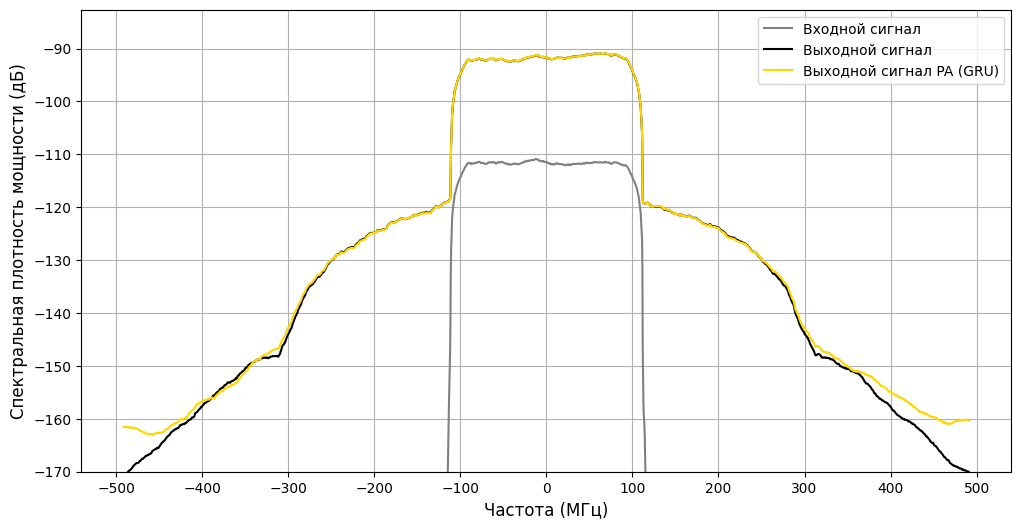

In [6]:
window_size = 50

freqs, spectrum_x_val = metrics.power_spectrum(container.val_input, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val = metrics.power_spectrum(container.val_output, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_pa = metrics.power_spectrum(y_val_pa, container.input_signal_fs, container.nperseg, window_size)

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности (дБ)"
fontsize = 12
figsize=(12, 6)

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, spectrum_x_val, color='grey', label='Входной сигнал')
plt.plot(freqs / 1e6, spectrum_y_val, color='black', label='Выходной сигнал')
plt.plot(freqs / 1e6, spectrum_pa, color='gold', label='Выходной сигнал PA (GRU)')


plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.legend()
plt.ylim(bottom=-170)
plt.xticks(np.arange(-500, 600, 100))
plt.grid()
plt.show()


ILC DPD

In [10]:
u_k_train = learning.ilc_signal(container.train_input, container.train_output_target, pa_model, epochs=200, learning_rate=0.01)
u_k_val = learning.ilc_signal(container.val_input, container.val_output_target, pa_model, epochs=200, learning_rate=0.01)
u_k_pa = pa_model.forward(u_k_train).detach()

nmse_uk_pa = metrics.compute_nmse(u_k_pa, container.train_output_target)
print(f"NMSE на выходе усилителя (ILC): {nmse_uk_pa:.2f} db")

container.ilc_train_output = u_k_train
container.ilc_val_output = u_k_val



Epoch [0/200], Loss: 0.004443641286343336
Epoch [100/200], Loss: 8.294723130575221e-08
Epoch [199/200], Loss: 2.2939243837782897e-09
Выполнение заняло: 0:01:59
Epoch [0/200], Loss: 0.004412407521158457
Epoch [100/200], Loss: 8.252550998122388e-08
Epoch [199/200], Loss: 5.0308555064881855e-12
Выполнение заняло: 0:00:27
NMSE на выходе усилителя (ILC): -70.27 db


In [12]:
# lstm

ilc_train_loader, ilc_val_loader, ilc_input_norm, ilc_target_norm = data_loader.build_dataloaders(container, 
                                                                            frame_length=frame_length,
                                                                            batch_size=batch_size, 
                                                                            batch_size_eval=batch_size_eval,
                                                                            arch="ilc",
                                                                            normalize_method='standard')

In [ ]:
# #leann

# ilc_train_loader, ilc_val_loader, ilc_input_norm, ilc_target_norm = data_loader.build_nn_dataloaders(container, 
#                                                                             batch_size=batch_size, 
#                                                                             batch_size_eval=batch_size_eval,
#                                                                             arch="ilc",
#                                                                             features_extractor=data_loader.build_LEANN_features,
#                                                                             normalize_method='standard',
#                                                                             M=M)

In [ ]:
# #rtdtnn

# ilc_train_loader, ilc_val_loader, ilc_input_norm, ilc_target_norm = data_loader.build_nn_dataloaders(container, 
#                                                                             batch_size=batch_size, 
#                                                                             batch_size_eval=batch_size_eval,
#                                                                             arch="ilc",
#                                                                             features_extractor=data_loader.build_RTDTNN_features,
#                                                                             normalize_method='standard',
#                                                                             M=M)

In [ ]:
L1 = 16
L2 = 8
L3 = 16
K = 3

epochs = 200
lr = 0.01
model_ilc = KPLEANNCombined(M=M, L2=L2, L3=L3, K=K, L1=L1, model_name="ilc")

print(f"total_params: {model_ilc.count_params()}")
is_load = model_ilc.load_weights()

optimizer = torch.optim.AdamW(model_ilc.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not is_load:
    learning.train(net=model_ilc, 
                criterion=criterion, 
                optimizer=optimizer, 
                train_loader=ilc_train_loader, 
                val_loader=ilc_val_loader, 
                n_epochs=epochs, 
                metric_criterion=metric_criterion,
                scheduler=scheduler)
    model_ilc.save_weights()

norm_val_input = ilc_input_norm.transform(container.val_input)
x_val_in = norm_val_input

y_before_pa = learning.net_inference(net=model_ilc, x=x_val_in)
y_before_pa = ilc_target_norm.inverse_transform(y_before_pa)

casc_ilc_eval = utils.CascadeModel(model_1=model_ilc, model_2=pa_model, normalizer=ilc_target_norm)
y_val_ilc = learning.net_inference(net=casc_ilc_eval, x=x_val_in)

pa_nmse = metrics.compute_nmse(y_val_ilc, container.val_output_target)
print(f"Model NMSE: {pa_nmse:.2f}")

pa_acpr = metrics.calculate_acpr(y_val_ilc, acpr_meter)
print(f"Model ACPR: {pa_acpr[0]:.2f} {pa_acpr[1]:.2f}")

In [ ]:
epochs = 200
lr = 0.01
model_ilc = KPRTDTNNCombined(M=M, 
                             d_model=10, 
                             n_heads=2, 
                             d_ff=10, 
                             n_fc=2,
                             num_blocks=2, 
                             model_name="ilc")

print(f"total_params: {model_ilc.count_params()}")
is_load = model_ilc.load_weights()

optimizer = torch.optim.AdamW(model_ilc.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not is_load:
    learning.train(net=model_ilc, 
                criterion=criterion, 
                optimizer=optimizer, 
                train_loader=ilc_train_loader, 
                val_loader=ilc_val_loader, 
                n_epochs=epochs, 
                metric_criterion=metric_criterion,
                scheduler=scheduler)
    model_ilc.save_weights()

norm_val_input = ilc_input_norm.transform(container.val_input)
x_val_in = norm_val_input

y_before_pa = learning.net_inference(net=model_ilc, x=x_val_in)
y_before_pa = ilc_target_norm.inverse_transform(y_before_pa)

casc_ilc_eval = utils.CascadeModel(model_1=model_ilc, model_2=pa_model, normalizer=ilc_target_norm)
y_val_ilc = learning.net_inference(net=casc_ilc_eval, x=x_val_in)

ilc_nmse = metrics.compute_nmse(y_val_ilc, container.val_output_target)
print(f"Model NMSE: {ilc_nmse:.2f}")

ilc_acpr = metrics.calculate_acpr(y_val_ilc, acpr_meter)
print(f"Model ACPR: {ilc_acpr[0]:.2f} {ilc_acpr[1]:.2f}")

In [27]:
epochs = 300
lr = 0.01
model_ilc = KPLSTM(M=M, hidden_size=8, num_layers=1, reduced_dim=8, model_name="ilc")

print(f"total_params: {model_ilc.count_params()}")
is_load = model_ilc.load_weights()

optimizer = torch.optim.AdamW(model_ilc.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not is_load:
    learning.train(net=model_ilc, 
                criterion=criterion, 
                optimizer=optimizer, 
                train_loader=ilc_train_loader, 
                val_loader=ilc_val_loader, 
                n_epochs=epochs, 
                metric_criterion=metric_criterion,
                scheduler=scheduler)
    model_ilc.save_weights()

x_val_in = ilc_input_norm.transform(container.val_input)
# x_val_in = norm_val_input

y_before_pa = learning.net_inference(net=model_ilc, x=x_val_in)
y_before_pa = ilc_target_norm.inverse_transform(y_before_pa)

casc_ilc_eval = utils.CascadeModel(model_1=model_ilc, model_2=pa_model, normalizer=ilc_target_norm)
y_val_ilc = learning.net_inference(net=casc_ilc_eval, x=x_val_in)

ilc_nmse = metrics.compute_nmse(y_val_ilc, container.val_output_target)
print(f"Model NMSE: {ilc_nmse:.2f}")

ilc_acpr = metrics.calculate_acpr(y_val_ilc, acpr_meter)
print(f"Model ACPR: {ilc_acpr[0]:.2f} {ilc_acpr[1]:.2f}")

total_params: 2018
Model weights loaded from model_params/ilc_KPLSTM_hs8_nl1_out2_bi0_M5_K5_rd8_fd152_kpconv.pt
Model NMSE: -49.32
Model ACPR: -63.03 -64.16


In [26]:
epochs = 300
lr = 0.01
model_ilc = KPTCN(M=M, hidden_channels=22, kernel_size=4, reduced_dim=8, model_name="ilc")

print(f"total_params: {model_ilc.count_params()}")
is_load = model_ilc.load_weights()

optimizer = torch.optim.AdamW(model_ilc.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not is_load:
    learning.train(net=model_ilc, 
                criterion=criterion, 
                optimizer=optimizer, 
                train_loader=ilc_train_loader, 
                val_loader=ilc_val_loader, 
                n_epochs=epochs, 
                metric_criterion=metric_criterion,
                scheduler=scheduler)
    model_ilc.save_weights()

norm_val_input = ilc_input_norm.transform(container.val_input)
x_val_in = norm_val_input

y_before_pa = learning.net_inference(net=model_ilc, x=x_val_in)
y_before_pa = ilc_target_norm.inverse_transform(y_before_pa)

casc_ilc_eval = utils.CascadeModel(model_1=model_ilc, model_2=pa_model, normalizer=ilc_target_norm)
y_val_ilc = learning.net_inference(net=casc_ilc_eval, x=x_val_in)

ilc_nmse = metrics.compute_nmse(y_val_ilc, container.val_output_target)
print(f"Model NMSE: {ilc_nmse:.2f}")

ilc_acpr = metrics.calculate_acpr(y_val_ilc, acpr_meter)
print(f"Model ACPR: {ilc_acpr[0]:.2f} {ilc_acpr[1]:.2f}")

total_params: 2036
No saved weights found at model_params/ilc_KPTCN_hc22_oc2_ks4_M5_K5_rd8_fd152_kpconv.pt, initializing new parameters.
===Start training===
Epoch 0000 — train_loss: 0.05329090, val_loss: 0.00056038, val_NMSE: -31.95, lr: 0.01
Epoch 0001 — train_loss: 0.00076375, val_loss: 0.00041982, val_NMSE: -33.20, lr: 0.01
Epoch 0002 — train_loss: 0.00041923, val_loss: 0.00013391, val_NMSE: -38.17, lr: 0.01
Epoch 0003 — train_loss: 0.00032860, val_loss: 0.00014145, val_NMSE: -37.93, lr: 0.01
Epoch 0004 — train_loss: 0.00026149, val_loss: 0.00011670, val_NMSE: -38.76, lr: 0.01
Epoch 0005 — train_loss: 0.00022272, val_loss: 0.00007578, val_NMSE: -40.64, lr: 0.01
Epoch 0006 — train_loss: 0.00019856, val_loss: 0.00005486, val_NMSE: -42.04, lr: 0.01
Epoch 0007 — train_loss: 0.00018948, val_loss: 0.00005147, val_NMSE: -42.32, lr: 0.01
Epoch 0008 — train_loss: 0.00017507, val_loss: 0.00005338, val_NMSE: -42.16, lr: 0.01
Epoch 0009 — train_loss: 0.00015823, val_loss: 0.00004408, val_NMSE:

In [13]:
epochs = 200
lr = 0.01
model_ilc = TCN(hidden_channels=96, kernel_size=4, model_name="ilc")

print(f"total_params: {model_ilc.count_params()}")
is_load = model_ilc.load_weights()

optimizer = torch.optim.AdamW(model_ilc.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not is_load:
    learning.train(net=model_ilc, 
                criterion=criterion, 
                optimizer=optimizer, 
                train_loader=ilc_train_loader, 
                val_loader=ilc_val_loader, 
                n_epochs=epochs, 
                metric_criterion=metric_criterion,
                scheduler=scheduler)
    model_ilc.save_weights()

norm_val_input = ilc_input_norm.transform(container.val_input)
x_val_in = norm_val_input

y_before_pa = learning.net_inference(net=model_ilc, x=x_val_in)
y_before_pa = ilc_target_norm.inverse_transform(y_before_pa)

casc_ilc_eval = utils.CascadeModel(model_1=model_ilc, model_2=pa_model, normalizer=ilc_target_norm)
y_val_ilc = learning.net_inference(net=casc_ilc_eval, x=x_val_in)

ilc_nmse = metrics.compute_nmse(y_val_ilc, container.val_output_target)
print(f"Model NMSE: {ilc_nmse:.2f}")

ilc_acpr = metrics.calculate_acpr(y_val_ilc, acpr_meter)
print(f"Model ACPR: {ilc_acpr[0]:.2f} {ilc_acpr[1]:.2f}")

total_params: 2016
Model weights loaded from model_params/ilc_TCN_ic2_hc96_oc2_ks4.pt
Model NMSE: -48.45
Model ACPR: -62.30 -62.40


In [18]:
epochs = 300
lr = 0.01
model_ilc = KPGRU(M=M, hidden_size=10, reduced_dim=8, num_layers=1, model_name="ilc")

print(f"total_params: {model_ilc.count_params()}")
is_load = model_ilc.load_weights()

optimizer = torch.optim.AdamW(model_ilc.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not is_load:
    learning.train(net=model_ilc, 
                criterion=criterion, 
                optimizer=optimizer, 
                train_loader=ilc_train_loader, 
                val_loader=ilc_val_loader, 
                n_epochs=epochs, 
                metric_criterion=metric_criterion,
                scheduler=scheduler)
    model_ilc.save_weights()

x_val_in = ilc_input_norm.transform(container.val_input)

y_before_pa = learning.net_inference(net=model_ilc, x=x_val_in)
y_before_pa = ilc_target_norm.inverse_transform(y_before_pa)

casc_ilc_eval = utils.CascadeModel(model_1=model_ilc, model_2=pa_model, normalizer=ilc_target_norm)
y_val_ilc = learning.net_inference(net=casc_ilc_eval, x=x_val_in)

ilc_nmse = metrics.compute_nmse(y_val_ilc, container.val_output_target)
print(f"Model NMSE: {ilc_nmse:.2f}")

ilc_acpr = metrics.calculate_acpr(y_val_ilc, acpr_meter)
print(f"Model ACPR: {ilc_acpr[0]:.2f} {ilc_acpr[1]:.2f}")

total_params: 2046
No saved weights found at model_params/ilc_KPGRU_hs10_nl1_out2_bi0_M5_K5_rd8_fd152_kpconv.pt, initializing new parameters.
===Start training===
Epoch 0000 — train_loss: 0.03208911, val_loss: 0.00092886, val_NMSE: -29.75, lr: 0.01
Epoch 0001 — train_loss: 0.00123629, val_loss: 0.00036155, val_NMSE: -33.85, lr: 0.01
Epoch 0002 — train_loss: 0.00079919, val_loss: 0.00031173, val_NMSE: -34.50, lr: 0.01
Epoch 0003 — train_loss: 0.00062035, val_loss: 0.00029206, val_NMSE: -34.78, lr: 0.01
Epoch 0004 — train_loss: 0.00053166, val_loss: 0.00028929, val_NMSE: -34.82, lr: 0.01
Epoch 0005 — train_loss: 0.00045885, val_loss: 0.00027897, val_NMSE: -34.98, lr: 0.01
Epoch 0006 — train_loss: 0.00038753, val_loss: 0.00019072, val_NMSE: -36.63, lr: 0.01
Epoch 0007 — train_loss: 0.00035662, val_loss: 0.00015545, val_NMSE: -37.52, lr: 0.01
Epoch 0008 — train_loss: 0.00032227, val_loss: 0.00012733, val_NMSE: -38.38, lr: 0.01
Epoch 0009 — train_loss: 0.00027714, val_loss: 0.00009013, val_

In [24]:
window_size = 50

freqs, spectrum_y_in = metrics.power_spectrum(container.val_input, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_out = metrics.power_spectrum(container.val_output, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_pa = metrics.power_spectrum(y_val_pa, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_target = metrics.power_spectrum(container.val_output_target, container.input_signal_fs, container.nperseg, window_size)

# _, spectrum_y_dpd_dla = metrics.power_spectrum(y_dpd_dla, container.input_signal_fs, container.nperseg, window_size)
# _, spectrum_y_dpd_ila = metrics.power_spectrum(y_dpd_ila, container.input_signal_fs, container.nperseg, window_size)
# _, spectrum_y_dpd_ilc = metrics.power_spectrum(y_dpd_ilc, container.input_signal_fs, container.nperseg, window_size)

# _, spectrum_y_val_dla = metrics.power_spectrum(y_val_dla, container.input_signal_fs, container.nperseg, window_size)
# _, spectrum_y_val_ila = metrics.power_spectrum(y_val_ila, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_ilc = metrics.power_spectrum(y_val_ilc, container.input_signal_fs, container.nperseg, window_size)


# _, spectrum_u_k = metrics.power_spectrum(u_k_val, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_u_k_pa = metrics.power_spectrum(u_k_pa, container.input_signal_fs, container.nperseg, window_size)

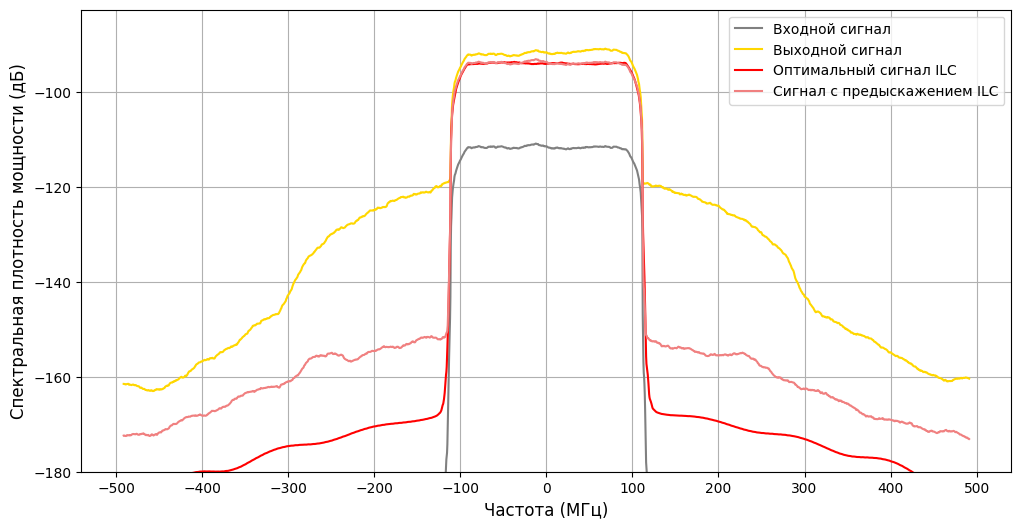

In [25]:
# построение спектра

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности (дБ)"
fontsize = 12
figsize=(12, 6)

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, spectrum_y_in, color='grey', label='Входной сигнал')
plt.plot(freqs / 1e6, spectrum_y_val_pa, color='gold', label='Выходной сигнал')
plt.plot(freqs / 1e6, spectrum_u_k_pa, color='red', label='Оптимальный сигнал ILC')
# plt.plot(freqs / 1e6, spectrum_y_val_dla, color='darkorange', label='Сигнал с предыскажением DLA')
# plt.plot(freqs / 1e6, spectrum_y_val_ila, color='limegreen', label='Сигнал с предыскажением ILA')
plt.plot(freqs / 1e6, spectrum_y_val_ilc, color='lightcoral', label='Сигнал с предыскажением ILC')


plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.xticks(np.arange(-500, 600, 100))
plt.legend()
plt.ylim(bottom=-180)
plt.grid()
plt.show()



Metrics

In [14]:

kplstm_conv_r4_train_props = {
    "M": M,
    "hidden_size": 14,
    "num_layers": 1,
    "reduced_dim": 4,
    "kp_type": "conv",
    "bidirectional": False,
    "lr": 0.01,
    "epochs": 300,
    "acpr_meter": acpr_meter,
}

kplstm_conv_r4_pipeline = pipelines.SimplePipeline(container=container, 
                              train_props=kplstm_conv_r4_train_props, 
                              base_model=KPLSTM,
                              pa_model=pa_model)


kplstm_conv_r4_stats = kplstm_conv_r4_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

kplstm_conv_r4_agg_stats = metrics.summarize_statistics(kplstm_conv_r4_stats)

kplstm_conv_r4_results = kplstm_conv_r4_pipeline.get_results()

kplstm_conv_r4_count = kplstm_conv_r4_results["ilc"]["count_params"]

final_kplstm_conv_r4_stats = {
        "Model": "kplstm_conv_r4",
        "Params": kplstm_conv_r4_count,
        "NMSE (dB)": round(kplstm_conv_r4_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(kplstm_conv_r4_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(kplstm_conv_r4_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_kplstm_conv_r4_stats)


=== Run 1/5 ===
Run ILC
count_params: 1962
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.04500198, val_loss: 0.00145822, val_NMSE: -27.80, lr: 0.01
Epoch 0001 — train_loss: 0.00184759, val_loss: 0.00064591, val_NMSE: -31.33, lr: 0.01
Epoch 0002 — train_loss: 0.00109271, val_loss: 0.00040384, val_NMSE: -33.37, lr: 0.01
Epoch 0003 — train_loss: 0.00085161, val_loss: 0.00035454, val_NMSE: -33.94, lr: 0.01
Epoch 0004 — train_loss: 0.00067312, val_loss: 0.00020358, val_NMSE: -36.35, lr: 0.01
Epoch 0005 — train_loss: 0.00056723, val_loss: 0.00036147, val_NMSE: -33.85, lr: 0.01
Epoch 0006 — train_loss: 0.00049508, val_loss: 0.00032634, val_NMSE: -34.30, lr: 0.01
Epoch 0007 — train_loss: 0.00048159, val_loss: 0.00018040, val_NMSE: -36.87, lr: 0.01
Epoch 0008 — train_loss: 0.00040418, val_loss: 0.00032165, val_NMSE: -34.36, lr: 0.01
Epoch 0009 — train_loss: 0.00039020, val_loss: 0.00037750, val_NMSE: -33.66, lr: 0.01
Epoch 0010 — train_loss: 0.00037606,

In [15]:

kplstm_conv_r8_train_props = {
    "M": M,
    "hidden_size": 14,
    "num_layers": 1,
    "reduced_dim": 8,
    "kp_type": "conv",
    "bidirectional": False,
    "lr": 0.01,
    "epochs": 300,
    "acpr_meter": acpr_meter,
}

kplstm_conv_r8_pipeline = pipelines.SimplePipeline(container=container, 
                              train_props=kplstm_conv_r8_train_props, 
                              base_model=KPLSTM,
                              pa_model=pa_model)


kplstm_conv_r8_stats = kplstm_conv_r8_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

kplstm_conv_r8_agg_stats = metrics.summarize_statistics(kplstm_conv_r8_stats)

kplstm_conv_r8_results = kplstm_conv_r8_pipeline.get_results()

kplstm_conv_r8_count = kplstm_conv_r8_results["ilc"]["count_params"]

final_kplstm_conv_r8_stats = {
        "Model": "kplstm_conv_r8",
        "Params": kplstm_conv_r8_count,
        "NMSE (dB)": round(kplstm_conv_r8_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(kplstm_conv_r8_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(kplstm_conv_r8_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_kplstm_conv_r8_stats)


=== Run 1/5 ===
Run ILC
count_params: 2798
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.03425832, val_loss: 0.00164283, val_NMSE: -27.28, lr: 0.01
Epoch 0001 — train_loss: 0.00158989, val_loss: 0.00050950, val_NMSE: -32.36, lr: 0.01
Epoch 0002 — train_loss: 0.00092140, val_loss: 0.00032810, val_NMSE: -34.27, lr: 0.01
Epoch 0003 — train_loss: 0.00073826, val_loss: 0.00033023, val_NMSE: -34.25, lr: 0.01
Epoch 0004 — train_loss: 0.00063651, val_loss: 0.00021771, val_NMSE: -36.05, lr: 0.01
Epoch 0005 — train_loss: 0.00054505, val_loss: 0.00023378, val_NMSE: -35.75, lr: 0.01
Epoch 0006 — train_loss: 0.00047301, val_loss: 0.00018134, val_NMSE: -36.85, lr: 0.01
Epoch 0007 — train_loss: 0.00042833, val_loss: 0.00026494, val_NMSE: -35.20, lr: 0.01
Epoch 0008 — train_loss: 0.00040274, val_loss: 0.00014760, val_NMSE: -37.74, lr: 0.01
Epoch 0009 — train_loss: 0.00038200, val_loss: 0.00031383, val_NMSE: -34.47, lr: 0.01
Epoch 0010 — train_loss: 0.00035563,

In [16]:

kplstm_linear_r4_train_props = {
    "M": M,
    "hidden_size": 14,
    "num_layers": 1,
    "reduced_dim": 4,
    "kp_type": "linear",
    "bidirectional": False,
    "lr": 0.01,
    "epochs": 300,
    "acpr_meter": acpr_meter,
}

kplstm_linear_r4_pipeline = pipelines.SimplePipeline(container=container, 
                              train_props=kplstm_linear_r4_train_props, 
                              base_model=KPLSTM,
                              pa_model=pa_model)


kplstm_linear_r4_stats = kplstm_linear_r4_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

kplstm_linear_r4_agg_stats = metrics.summarize_statistics(kplstm_linear_r4_stats)

kplstm_linear_r4_results = kplstm_linear_r4_pipeline.get_results()

kplstm_linear_r4_count = kplstm_linear_r4_results["ilc"]["count_params"]

final_kplstm_linear_r4_stats = {
        "Model": "kplstm_linear_r4",
        "Params": kplstm_linear_r4_count,
        "NMSE (dB)": round(kplstm_linear_r4_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(kplstm_linear_r4_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(kplstm_linear_r4_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_kplstm_linear_r4_stats)


=== Run 1/5 ===
Run ILC
count_params: 1994
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.03686338, val_loss: 0.00138518, val_NMSE: -28.02, lr: 0.01
Epoch 0001 — train_loss: 0.00228813, val_loss: 0.00059164, val_NMSE: -31.71, lr: 0.01
Epoch 0002 — train_loss: 0.00136301, val_loss: 0.00036688, val_NMSE: -33.79, lr: 0.01
Epoch 0003 — train_loss: 0.00098247, val_loss: 0.00027239, val_NMSE: -35.08, lr: 0.01
Epoch 0004 — train_loss: 0.00083929, val_loss: 0.00021749, val_NMSE: -36.06, lr: 0.01
Epoch 0005 — train_loss: 0.00070284, val_loss: 0.00028468, val_NMSE: -34.89, lr: 0.01
Epoch 0006 — train_loss: 0.00062175, val_loss: 0.00015508, val_NMSE: -37.53, lr: 0.01
Epoch 0007 — train_loss: 0.00054711, val_loss: 0.00042004, val_NMSE: -33.20, lr: 0.01
Epoch 0008 — train_loss: 0.00051096, val_loss: 0.00012543, val_NMSE: -38.45, lr: 0.01
Epoch 0009 — train_loss: 0.00046454, val_loss: 0.00032667, val_NMSE: -34.29, lr: 0.01
Epoch 0010 — train_loss: 0.00045731,

In [17]:

kp_results = [final_kplstm_conv_r4_stats, 
               final_kplstm_conv_r8_stats, 
               final_kplstm_linear_r4_stats,]

df = pd.DataFrame(kp_results)
df = df.sort_values(by=["NMSE (dB)", "ACPR left (dB)", "ACPR right (dB)"], ascending=[False, False, False])

print(df)

# df.to_excel("kp_results.xlsx", index=False)

              Model  Params  NMSE (dB)  ACPR left (dB)  ACPR right (dB)
2  kplstm_linear_r4    1994     -49.41          -63.69           -64.60
0    kplstm_conv_r4    1962     -50.53          -63.39           -64.63
1    kplstm_conv_r8    2798     -52.63          -64.15           -65.94
